In [1]:
import pandas as pd
import numpy as np
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read in clustering results
cells = pd.read_csv('../data/patient_metacluster_table_patient_updated.csv', index_col=0)
cells.head()

,FileNames,metacluster_1,metacluster_10,metacluster_11,metacluster_12,metacluster_13,metacluster_14,metacluster_15,metacluster_16,metacluster_17,...,Patient_ID,Timepoint,Batch_Control,Reference,Batch_Control_Type,Healthy,Disease,Batch,X7_month_response,X12_month_response
0,P08_C1_D8_Myeloid_Panel,9894.0,0.0,2569.0,30246.0,4.0,1323.0,6842.0,5517.0,82.0,...,P08,C1_D8,C1_D8,False,not_control,Sample,MDS,8,Non_responder,Progression
1,P08_C7_D1_Myeloid_Panel,2411.0,0.0,257.0,2476.0,2.0,429.0,1703.0,754.0,10.0,...,P08,C7_D1,C7_D1,False,not_control,Sample,MDS,8,Non_responder,Progression
2,P08_C7_D22_Myeloid_Panel,454.0,0.0,13.0,114.0,0.0,35.0,207.0,469.0,0.0,...,P08,C7_D22,C7_D22,False,not_control,Sample,MDS,8,Non_responder,Progression
3,P08_SPD_Myeloid_Panel,373.0,0.0,14.0,146.0,2.0,50.0,83.0,320.0,2.0,...,P08,SPD,SPD,False,not_control,Sample,MDS,8,Non_responder,Progression
4,P24_C1_D1_Myeloid_Panel,18476.0,8.0,184.0,2058.0,106.0,180.0,2503.0,525.0,0.0,...,P24,C1_D1,C1_D1,False,not_control,Sample,AML,1,Non_responder,Off_trial_at_month_7


In [3]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
print(cells.shape)
cells = cells.loc[cells['FileNames'] != 'P02_SPD_Myeloid_Panel',:]
cells = cells.loc[~cells['FileNames'].str.contains('P26'),:]
cells['FileNames'] = cells['FileNames'].str.replace('P02_SPD_2_Myeloid_Panel', 'P02_SPD_Myeloid_Panel')
print(cells.shape)

(118, 52)
(115, 52)


In [4]:
# Read in clustering results which were updated 2025_05_20
cell_type = pd.read_csv('../data/myeloid_panel_clusters_2025_05_20.csv', index_col = 0)
cell_type_dict = dict(zip(cell_type.index, cell_type['cell_type']))
cell_type_dict

del cell_type

In [5]:
# Write a dictionary of cell types to cluster numbers
cell_dict = {}
for key, value in cell_type_dict.items():
    if value in cell_dict:
        cell_dict[value].append(str(key))
    else:
        cell_dict[value] = [str(key)]
cell_dict

{'HSPCs': ['1', '2'],
 'Aberrant_1': ['3'],
 'Aberrant_2': ['9'],
 'B_cell': ['16'],
 'Monocytes': ['19', '5', '6', '7', '8', '10', '13'],
 'Cytotoxic NK': ['32', '25', '37', '33', '38'],
 'CD38_B_cell': ['14'],
 'T_Cell': ['24', '30', '39'],
 'CD47_low_progenitor': ['15', '20'],
 'CD56_Myeloid': ['11', '23', '35'],
 'Cytokine NK': ['40'],
 'CD66_pos_CD16_neg': ['17'],
 'CD56_pos_T_Cell': ['26', '34', '36'],
 'Myeloid': ['27', '4', '12'],
 'Neutrophils': ['18', '21', '22', '28', '29', '31']}

In [6]:
# Alter the column names to replace the following string so that they are easier to delete
cells.columns = cells.columns.str.replace('metacluster_', '')
cells.columns

# Sum together the columns which belong to specific cell types
for new_col, cols_to_sum in cell_dict.items():
    cells[new_col] = cells[cols_to_sum].sum(axis=1)
    
# Drop columns with numerical names
cols = [str(i + 1) for i in range(40)]
cells.drop(columns=cols, inplace=True)

del cols

cells.head()

,FileNames,Date,Patient_ID,Timepoint,Batch_Control,Reference,Batch_Control_Type,Healthy,Disease,Batch,...,Cytotoxic NK,CD38_B_cell,T_Cell,CD47_low_progenitor,CD56_Myeloid,Cytokine NK,CD66_pos_CD16_neg,CD56_pos_T_Cell,Myeloid,Neutrophils
0,P08_C1_D8_Myeloid_Panel,2021_03_02,P08,C1_D8,C1_D8,False,not_control,Sample,MDS,8,...,22088.0,1323.0,31001.0,6926.0,3087.0,2710.0,82.0,3227.0,30600.0,5237.0
1,P08_C7_D1_Myeloid_Panel,2021_03_02,P08,C7_D1,C7_D1,False,not_control,Sample,MDS,8,...,2875.0,429.0,7672.0,1716.0,330.0,414.0,10.0,686.0,2574.0,708.0
2,P08_C7_D22_Myeloid_Panel,2021_03_02,P08,C7_D22,C7_D22,False,not_control,Sample,MDS,8,...,2095.0,35.0,7264.0,209.0,14.0,292.0,0.0,317.0,119.0,14.0
3,P08_SPD_Myeloid_Panel,2021_03_02,P08,SPD,SPD,False,not_control,Sample,MDS,8,...,1704.0,50.0,4566.0,88.0,18.0,145.0,2.0,206.0,148.0,13.0
4,P24_C1_D1_Myeloid_Panel,2020_03_17,P24,C1_D1,C1_D1,False,not_control,Sample,AML,1,...,4533.0,180.0,23325.0,2513.0,208.0,322.0,0.0,1015.0,2176.0,35.0


In [7]:
# Remove the metacluster columns to simplify analysis
cells = cells.drop(cells.loc[:, 'Date' : 'X12_month_response',], axis = 1)

In [8]:
# Add a column which details total T cells
cells['Total_T_cells'] = cells['T_Cell'] + cells['CD56_pos_T_Cell']
cells['Total_NK'] = cells['Cytotoxic NK'] + cells['Cytokine NK'] 
cells.head()

,FileNames,HSPCs,Aberrant_1,Aberrant_2,B_cell,Monocytes,Cytotoxic NK,CD38_B_cell,T_Cell,CD47_low_progenitor,CD56_Myeloid,Cytokine NK,CD66_pos_CD16_neg,CD56_pos_T_Cell,Myeloid,Neutrophils,Total_T_cells,Total_NK
0,P08_C1_D8_Myeloid_Panel,10701.0,185.0,8514.0,5517.0,538.0,22088.0,1323.0,31001.0,6926.0,3087.0,2710.0,82.0,3227.0,30600.0,5237.0,34228.0,24798.0
1,P08_C7_D1_Myeloid_Panel,2545.0,18.0,246.0,754.0,48.0,2875.0,429.0,7672.0,1716.0,330.0,414.0,10.0,686.0,2574.0,708.0,8358.0,3289.0
2,P08_C7_D22_Myeloid_Panel,479.0,7.0,29.0,469.0,3.0,2095.0,35.0,7264.0,209.0,14.0,292.0,0.0,317.0,119.0,14.0,7581.0,2387.0
3,P08_SPD_Myeloid_Panel,387.0,1.0,33.0,320.0,6.0,1704.0,50.0,4566.0,88.0,18.0,145.0,2.0,206.0,148.0,13.0,4772.0,1849.0
4,P24_C1_D1_Myeloid_Panel,19467.0,78.0,44.0,525.0,2306.0,4533.0,180.0,23325.0,2513.0,208.0,322.0,0.0,1015.0,2176.0,35.0,24340.0,4855.0


In [9]:
# Use for loops to add patient information (which is encoded in column called FileNames 
# of the dataframe called cells) 
pid = []
timepoint = []
for i in cells['FileNames']:
    if i.startswith('P'):
        pid.append(i.split('_')[0])
        x = i.split('_')[1] + i.split('_')[2]
        x = x.replace('SPDMyeloid', 'Progression')
        timepoint.append(x)
    elif i.startswith('Control'):
        pid.append(i.split('_')[0] + '_' + i.split('_')[1])
        timepoint.append('Healthy')
        

timepoint = [i.replace('_Myeloid', '') for i in timepoint]
    
cells['PID'] = pid
cells['Timepoint'] = timepoint

del pid
del timepoint


In [10]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx', nrows = 40)
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes

diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))
outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))
outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))


In [11]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['PID'].map(diagnosis_dx)
cells['outcome_6'] = cells['PID'].map(outcome_C6_dx)
cells['outcome_12'] = cells['PID'].map(outcome_C12_dx)
cells

pid_timepoint = []
for x, y in zip(cells['PID'], cells['Timepoint']):
    if x.startswith('P'):
        pid_timepoint.append(x + '_' + y)
    else:
        pid_timepoint.append(x)

cells['pid_timepoint'] = pid_timepoint
#cells['pid_timepoint'] = cells['pid_timepoint'].astype(str)

In [12]:
# Read in data from Julie. This dataframe contains the patient outcomes and time when a sample was collected 
timepoints = pd.read_excel('../data/MS_flow_outcome_dx_clean_updatedJan24_patient_updated.xlsx')
timepoints['PID_Timepoint'] = timepoints['PID'].astype(str) + '_' + timepoints['Cycle_day']
to_keep = ['Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint']
timepoints = timepoints.loc[:,timepoints.columns.isin(to_keep)]
timepoints.head()
cells1 = pd.merge(cells, timepoints, left_on='pid_timepoint', right_on= 'PID_Timepoint', how = 'left')


# Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set       
diagnosis = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells1['PID'], cells1['diagnosis'])]
        
outcome_6 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells1['PID'], cells1['outcome_6'])]

outcome_12 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells1['PID'], cells1['outcome_12'])]
        
cells1['diagnosis'] = diagnosis
cells1['outcome_6'] = outcome_6
cells1['outcome_12'] = outcome_12

cells1[['diagnosis', 'outcome_6', 'outcome_12']] = cells1[['diagnosis', 'outcome_6', 'outcome_12']].fillna('Control')

In [13]:
# Use a dictionary to add a column called time which will be used for plotting
time = {'C1D1': 1, 'C1D8': 8, 'C7D1': 168, 'C7D22': 190, 'C12D29': 336,
    'Progression': 275,  'Healthy': 0.4}
    
cells1['time'] = cells1['Timepoint'].map(time)
cells1.head()

,FileNames,HSPCs,Aberrant_1,Aberrant_2,B_cell,Monocytes,Cytotoxic NK,CD38_B_cell,T_Cell,CD47_low_progenitor,...,Timepoint,diagnosis,outcome_6,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time
0,P08_C1_D8_Myeloid_Panel,10701.0,185.0,8514.0,5517.0,538.0,22088.0,1323.0,31001.0,6926.0,...,C1D8,MDS,non-responder_2,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0
1,P08_C7_D1_Myeloid_Panel,2545.0,18.0,246.0,754.0,48.0,2875.0,429.0,7672.0,1716.0,...,C7D1,MDS,non-responder_2,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1,168.0
2,P08_C7_D22_Myeloid_Panel,479.0,7.0,29.0,469.0,3.0,2095.0,35.0,7264.0,209.0,...,C7D22,MDS,non-responder_2,non-responder_2,P08_C7D22,C7D22,238.0,264.0,P08_C7D22,190.0
3,P08_SPD_Myeloid_Panel,387.0,1.0,33.0,320.0,6.0,1704.0,50.0,4566.0,88.0,...,Progression,MDS,non-responder_2,non-responder_2,P08_Progression,Progression,350.0,376.0,P08_Progression,275.0
4,P24_C1_D1_Myeloid_Panel,19467.0,78.0,44.0,525.0,2306.0,4533.0,180.0,23325.0,2513.0,...,C1D1,AML,non-responder_2,Control,P24_C1D1,C1D1,0.0,21.0,P24_C1D1,1.0


In [15]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column
to_del = []
time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']
for x, y in zip(cells1['pid_timepoint'], cells1['outcome_12']):
    if x.__contains__('C7D22') & (y not in time_to_keep):
        to_del.append(x)

print(cells1.shape)
cells2 = cells1.loc[~cells1['pid_timepoint'].isin(to_del), :]
print(cells2.shape)

del to_del



(115, 29)
(113, 29)


In [16]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = []
for x, y in zip(cells2['outcome_6'], cells2['outcome_12']):
    if (x == 'responder_1') | (y == 'responder_1'):
        best_response.append('responder')
    elif (x == 'Control'):
        best_response.append('Control')
    else:
        best_response.append('non-responder')
    
        
cells2['best_response'] = best_response

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6474/2771573799.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells2['best_response'] = best_response


In [17]:
cells2['best_response'].unique()

array(['non-responder', 'responder', 'Control'], dtype=object)

In [18]:
cells2.columns

Index(['FileNames', 'HSPCs', 'Aberrant_1', 'Aberrant_2', 'B_cell', 'Monocytes',
       'Cytotoxic NK', 'CD38_B_cell', 'T_Cell', 'CD47_low_progenitor',
       'CD56_Myeloid', 'Cytokine NK', 'CD66_pos_CD16_neg', 'CD56_pos_T_Cell',
       'Myeloid', 'Neutrophils', 'Total_T_cells', 'Total_NK', 'PID',
       'Timepoint', 'diagnosis', 'outcome_6', 'outcome_12', 'pid_timepoint',
       'Cycle_day', 'Day_since_C1D1', 'Day_since_scr', 'PID_Timepoint', 'time',
       'best_response'],
      dtype='object')

In [19]:
# Turn the columns into a percent of CD34 or a percent of CD45 cells
cells2['total_cells'] = cells2.loc[:,'HSPCs':'Neutrophils'].sum(axis = 1)
cells2['total_cd34_neg'] = cells2['total_cells'] - cells2['HSPCs']

cells2.loc[:, 'HSPCs'] = cells2.loc[:, 'HSPCs'].divide(cells2.loc[:, 'total_cells'], axis =0) *100
cells2.loc[:, 'Aberrant_1': 'Total_NK'] = cells2.loc[:, 'Aberrant_1': 'Total_NK'].divide(cells2.loc[:, 'total_cd34_neg'], axis =0) *100
cells2

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6474/4122609147.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells2['total_cells'] = cells2.loc[:,'HSPCs':'Neutrophils'].sum(axis = 1)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6474/4122609147.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells2['total_cd34_neg'] = cells2['total_cells'] - cells2['HSPCs']


,FileNames,HSPCs,Aberrant_1,Aberrant_2,B_cell,Monocytes,Cytotoxic NK,CD38_B_cell,T_Cell,CD47_low_progenitor,...,outcome_12,pid_timepoint,Cycle_day,Day_since_C1D1,Day_since_scr,PID_Timepoint,time,best_response,total_cells,total_cd34_neg
0,P08_C1_D8_Myeloid_Panel,8.123064,0.152848,7.034329,4.558186,0.444500,18.249267,1.093072,25.613252,5.722312,...,non-responder_2,P08_C1D8,C1D8,9.0,35.0,P08_C1D8,8.0,non-responder,131736.0,121035.0
1,P08_C7_D1_Myeloid_Panel,12.104637,0.097403,1.331169,4.080087,0.259740,15.557359,2.321429,41.515152,9.285714,...,non-responder_2,P08_C7D1,C7D1,217.0,243.0,P08_C7D1,168.0,non-responder,21025.0,18480.0
2,P08_C7_D22_Myeloid_Panel,4.221752,0.064415,0.266863,4.315819,0.027607,19.278550,0.322076,66.844575,1.923254,...,non-responder_2,P08_C7D22,C7D22,238.0,264.0,P08_C7D22,190.0,non-responder,11346.0,10867.0
3,P08_SPD_Myeloid_Panel,5.034474,0.013699,0.452055,4.383562,0.082192,23.342466,0.684932,62.547945,1.205479,...,non-responder_2,P08_Progression,Progression,350.0,376.0,P08_Progression,275.0,non-responder,7687.0,7300.0
4,P24_C1_D1_Myeloid_Panel,34.316992,0.209340,0.118089,1.409018,6.188943,12.165862,0.483092,62.600644,6.744498,...,Control,P24_C1D1,C1D1,0.0,21.0,P24_C1D1,1.0,non-responder,56727.0,37260.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,Control_4_Myeloid_Panel,0.534474,0.647501,0.079258,7.756582,18.541107,6.072004,1.462923,42.434175,2.907039,...,Control,Control_4,NaN,NaN,NaN,NaN,0.4,Control,74840.0,74440.0
111,Control_12_Myeloid_Panel,0.410256,0.123584,0.411946,8.753862,2.162719,9.763131,0.154480,58.825953,2.193615,...,Control,Control_12,NaN,NaN,NaN,NaN,0.4,Control,9750.0,9710.0
112,Control_11_Myeloid_Panel,0.547167,0.255896,0.085299,8.949972,0.371050,3.716893,0.537382,69.533416,1.735830,...,Control,Control_11,NaN,NaN,NaN,NaN,0.4,Control,47152.0,46894.0
113,Control_3_Myeloid_Panel,0.868263,0.206023,0.122967,37.911507,38.194115,0.175821,0.022652,8.998145,2.627605,...,Control,Control_3,NaN,NaN,NaN,NaN,0.4,Control,93520.0,92708.0


In [20]:
# Map the timepoint to the unique integer values, to allow for easier plotting
timepoint_dict = {'C1D1' : 2, 'C1D8' : 3, 'C7D1': 4, 'C7D22' : 5, 'C12D29' : 6, 'Progression' : 7, 'Healthy': 1}
cells2['time1'] = cells2['Timepoint'].map(timepoint_dict)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6474/3630696022.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells2['time1'] = cells2['Timepoint'].map(timepoint_dict)


In [21]:
cells2['best_response'].unique()

array(['non-responder', 'responder', 'Control'], dtype=object)

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6474/981766392.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data = cells3, x = 'time1', y=figure_list[y], err_style = 'bars',
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6474/981766392.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data = cells3, x = 'time1', y=figure_list[y], err_style = 'bars',
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/var/fol

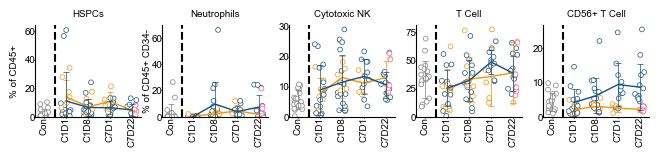

In [22]:
color_dict = {'non-responder':'#fe9003', 'responder':'#115284', 'Control': 'grey'}

# Set font to be arial and an editable text type
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 42 # export font as editable text


cells2_1 = cells2.copy()
cells2_1 = cells2_1.loc[cells2_1['Timepoint'] != 'C12D29', :]


fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (6.69 * 1, 6.69 * 0.25))
axs_flatten = axs.flatten()

stars = cells2_1.loc[cells2_1['Timepoint'] == 'Progression', :]['PID'].str.replace('_', '').to_list()

# Create a list of samples to plot
figure_list = [ 'HSPCs','Neutrophils', 'Cytotoxic NK', 'T_Cell',
  'CD56_pos_T_Cell', ]

# Use a for loop to add some jitter to the time column, this is done to allow for better visualisation of
# the individual data points in the graph
jitter_amount = 0.75
x_jitter = np.random.normal(1, jitter_amount, size=cells2_1.shape[0])

timejitter = []
for z, (w, x, y) in enumerate(zip(cells2_1['time1'], cells2_1['PID'], x_jitter)):
    if (w == 5) & (x in stars):
        timejitter.append(w + (y / 10))
    elif z % 2 == 0:
        timejitter.append(w + (y / 10))
    else:
        timejitter.append(w - (y / 10))

cells2_1['time2'] = timejitter
stars1 = cells2_1.loc[(cells2_1['PID'].isin(stars)) &  (cells2_1['Timepoint'] == 'C7D22'), :]
cells3 = cells2_1.loc[cells2_1['Timepoint'] != 'Progression',:]

for y, ax in enumerate(axs_flatten):
    if y >= len(figure_list):
        ax.axis('off')
    else:
            ax.scatter(x = cells3.loc[:,'time2'], y = cells3.loc[:, figure_list[y]], c = 'white',
              edgecolor = cells3.loc[:,'best_response'].map(color_dict),linewidth=0.5,    
                      alpha=1, 
                      s=12, rasterized=True)
            sns.lineplot(data = cells3, x = 'time1', y=figure_list[y], err_style = 'bars',
                 ci = 'sd',  err_kws={'linewidth': 0.5, 'capsize':2, 'capthick': 0.5}, legend = False, hue = 'best_response',
                     palette = color_dict, linewidth = 1, ax = ax)

                     
            ax.scatter(x = stars1['time2'], y = stars1[figure_list[y]], s = 12, color = 'white', linewidth=0.5,edgecolor = 'hotpink')
            
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.set_ylim(bottom = 0)
            e = str(figure_list[y])
            e = e.replace('_pos', '+')
            e = 'Myelo-prog' if e == 'Myeloid' else e
            e = e.replace('neg', '-')
            e = e.replace('_', ' ')
            
            ax.set_title(e, fontsize = 7)
            ax.axvline(1.5, color = 'black', ls = '--')
            ax.set_xticks([1, 2, 3, 4, 5])
            ax.set_xticklabels(['Con', 'C1D1', 'C1D8', 'C7D1', 'C7D22'], rotation = 90, fontsize = 7)
            ax.set_xlabel(xlabel = '',  fontsize = 7)
            ax.set_ylim(bottom = 0)
            
            # Get the axis limits
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
        
            # Calculate position as a percentage of the axis range
            x_pos = xmin + 0.25 * (xmax - xmin)  # 50% from left
            y_pos = ymax - 0.1 * (ymax - ymin)  # 5% from top
        

            if (y == 0):
                ax.set_ylabel('% of CD45+', fontsize  =7 )
            elif y == 1:
                ax.set_ylabel('% of CD45+ CD34-', fontsize  =7, labelpad = 0)
            else:
                ax.set_ylabel('', fontsize  =7 )
            ax.tick_params(axis='both', labelsize=7, pad = -1, length = 1)
plt.tight_layout(w_pad = 0.1)
#fig.savefig('linegraphs_for_paper_v2.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)